# Backtest Engine — Full Demo

Engine, 7 strategies, grid search, Monte Carlo, walk-forward, stress tests, alpha/beta, dark-mode plots.

In [43]:
%matplotlib inline
import sys
from pathlib import Path
_root = Path.cwd()
if (_root / 'src').exists(): pass
elif (_root.parent / 'src').exists(): _root = _root.parent
elif (_root.parent.parent / 'src').exists(): _root = _root.parent.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from src.backtest.engine import BacktestEngine, BacktestConfig, decompose_alpha_beta
from src.strategy import (
    SmaCrossStrategy, MeanReversionStrategy, HMMRegimeStrategy,
    RegimeRouterStrategy, IntensityGatedStrategy,
    VwapReversionStrategy, InstitutionalV3Strategy,
)
from src.backtest.monte_carlo import monte_carlo_simulate, MonteCarloConfig
from src.backtest.optimizer import grid_search, walk_forward_optimize, WalkForwardConfig
from src.backtest.stress_test import run_stress_tests
from src.backtest.visualization import (
    plot_equity_curve, plot_monte_carlo_fan, plot_stress_test,
    plot_param_heatmap, plot_walk_forward,
)
from src.features.indicators import compute_all
from src.features.volatility import realized_volatility, volatility_regime_labels, hawkes_intensity

import matplotlib.pyplot as plt
import yfinance as yf

## 2. Embedding-Inspired Strategy (S1 Hard70)

From  — best performer adapted to single-asset:
- Volatility rolling rank as intensity proxy (instead of cross-sectional embedding drift rank)
- Hard gate at 70th percentile — only trades when intensity is in top 30% of history
- Regime routing: reversal in high vol, momentum(3) in low vol

In [44]:
from src.strategy import S1Hard70Strategy

s1 = S1Hard70Strategy(
    vol_window=20, regime_percentile=50, mom_window=3,
    rev_window=1, gate_percentile=70, intensity_lookback=252,
)
r_s1 = engine.run(df_test, s1)
m = r_s1.metrics

pd.DataFrame({
    'metric': ['return', 'bh_return', 'excess', 'sharpe', 'max_dd', 'alpha', 'beta', 'trades'],
    'value': [
        f"{m['total_return_pct']:.1f}%",
        f"{m['bh_return_pct']:.1f}%",
        f"{m['excess_return_pct']:.1f}%",
        round(m['sharpe'], 2),
        f"{m['max_drawdown_pct']:.1f}%",
        f"{m['alpha_pct']:.1f}%",
        round(m['beta'], 2),
        int(m["trade_count"]),
    ]
})

,metric,value
0,return,-23.0%
1,bh_return,91.2%
2,excess,-114.2%
3,sharpe,-0.95
4,max_dd,-28.4%
5,alpha,-14.2%
6,beta,-0.04
7,trades,91


## 1. Real Data — VALE 5 years

In [45]:
tk = yf.Ticker("VALE")
df = tk.history(period="5y")
df.columns = [c.lower() for c in df.columns]
df["timestamp"] = df.index
df = df.dropna(subset=["close"]).sort_values("timestamp")

split = int(len(df) * 0.7)
df_train, df_test = df.iloc[:split], df.iloc[split:]

pd.DataFrame({
    '': ['train', 'test', 'full'],
    'days': [len(df_train), len(df_test), len(df)],
    'from': [str(df_train['timestamp'].iloc[0].date()), str(df_test['timestamp'].iloc[0].date()), str(df['timestamp'].iloc[0].date())],
    'to': [str(df_train['timestamp'].iloc[-1].date()), str(df_test['timestamp'].iloc[-1].date()), str(df['timestamp'].iloc[-1].date())],
})

,,days,from,to
0,train,878,2021-07-12,2025-01-06
1,test,377,2025-01-07,2026-07-10
2,full,1255,2021-07-12,2026-07-10


## 2. All Strategies vs Buy & Hold

In [46]:
config = BacktestConfig(initial_cash=10_000, fee_bps=4, slippage_bps=1, periods_per_year=252)
engine = BacktestEngine(config)

strategies = {
    'SMA 20/100': SmaCrossStrategy(20, 100),
    'SMA 10/50': SmaCrossStrategy(10, 50),
    'Mean Rev': MeanReversionStrategy(lookback=50, z_entry=1.5, z_exit=0.3),
    'Regime Router': RegimeRouterStrategy(vol_window=20, regime_percentile=50, mom_window=5),
    'Intensity Gated': IntensityGatedStrategy(vol_window=20, gate_percentile=70, gate_type='hard'),
    'Inst V3': InstitutionalV3Strategy(),
    'S1 Hard70': S1Hard70Strategy(vol_window=20, regime_percentile=50, mom_window=3, gate_percentile=70, intensity_lookback=252),
}

results = {}
rows = []
for name, strat in strategies.items():
    r = engine.run(df_test, strat)
    results[name] = r
    m = r.metrics
    rows.append({
        'strategy': name,
        'ret_%': round(m['total_return_pct'], 1),
        'bh_%': round(m['bh_return_pct'], 1),
        'excess_%': round(m['excess_return_pct'], 1),
        'sharpe': round(m['sharpe'], 2),
        'sortino': round(m['sortino'], 2),
        'max_dd_%': round(m['max_drawdown_pct'], 1),
        'cagr_%': round(m['cagr_pct'], 1),
        'calmar': round(m['calmar'], 2),
        'alpha_%': round(m['alpha_pct'], 1),
        'beta': round(m['beta'], 2),
        'r2': round(m['r_squared'], 2),
        'trades': int(m['trade_count']),
        'win_%': round(m['win_rate_pct'], 1),
        'pf': round(m['profit_factor'], 2),
    })

pd.DataFrame(rows).set_index('strategy')

,ret_%,bh_%,excess_%,sharpe,sortino,max_dd_%,cagr_%,calmar,alpha_%,beta,r2,trades,win_%,pf
strategy,,,,,,,,,,,,,,
SMA 20/100,56.3,91.2,-34.9,1.30,1.53,-19.9,34.8,1.75,1.9,0.65,0.64,12,0.0,0.0
SMA 10/50,18.8,91.2,-72.4,0.58,0.63,-26.2,12.2,0.47,-17.3,0.67,0.66,30,0.0,0.0
Mean Rev,-3.6,91.2,-94.8,0.03,0.04,-49.8,-2.4,-0.05,15.2,-0.30,0.14,206,0.0,0.0
Regime Router,-50.2,91.2,-141.4,-1.34,-1.82,-56.3,-37.2,-0.66,-48.2,0.13,0.01,315,0.0,0.0
Intensity Gated,-30.9,91.2,-122.1,-1.40,-0.94,-31.8,-21.9,-0.69,-24.0,0.01,-0.01,106,0.0,0.0
Inst V3,8.1,91.2,-83.1,0.80,0.52,-4.4,5.3,1.21,7.6,-0.04,0.04,16,0.0,0.0
S1 Hard70,-23.0,91.2,-114.2,-0.95,-0.65,-28.4,-16.0,-0.56,-14.2,-0.04,0.00,91,0.0,0.0


## 3. Equity Curves + BH Comparison

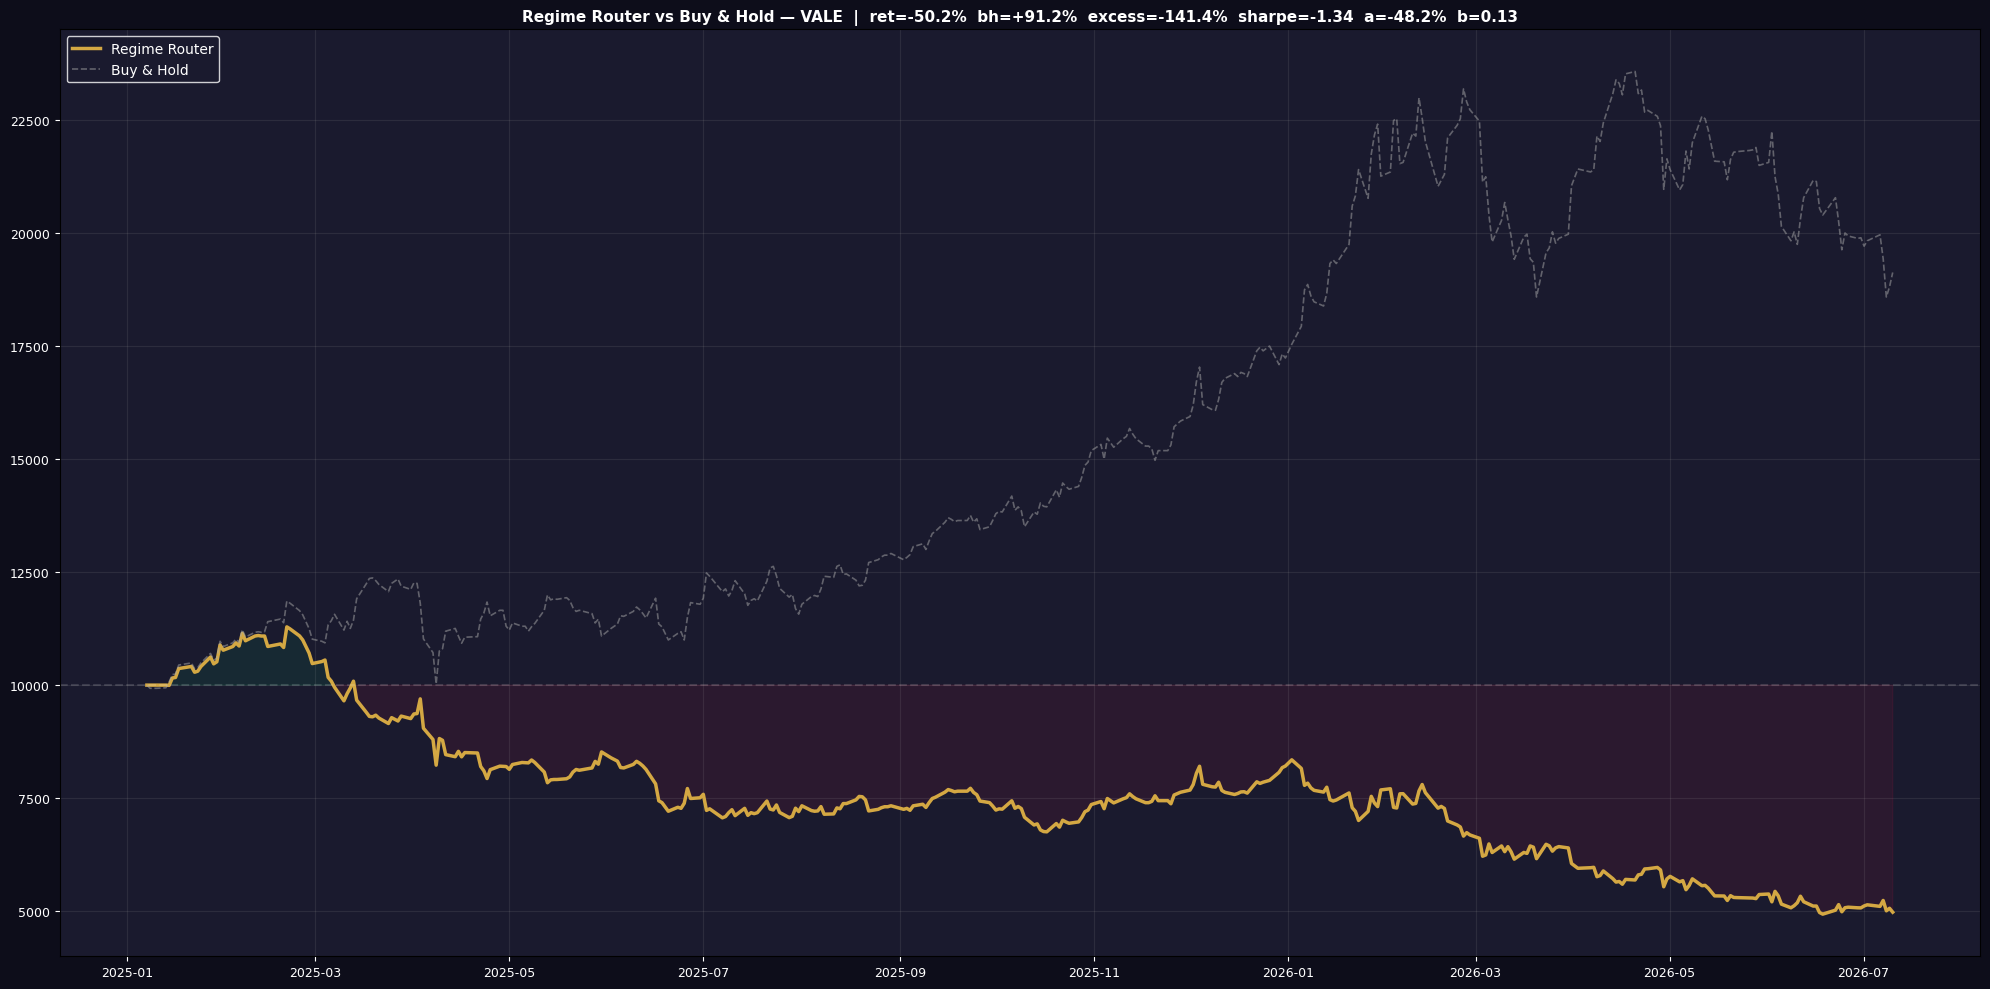

In [47]:
fig, ax = plt.subplots(figsize=(20, 10))
fig.patch.set_facecolor('#0d0d1a')

r = results['Regime Router']
eq = r.equity_curve.set_index('timestamp')['equity']
bh = df_test.set_index('timestamp')['close']
bh = bh / bh.iloc[0] * config.initial_cash
dd = (eq / eq.cummax() - 1) * 100

ax.plot(eq.index, eq.values, color='#D4A843', lw=2.5, label='Regime Router')
ax.plot(bh.index, bh.values, color='#AAAAAA', lw=1.2, ls='--', alpha=0.5, label='Buy & Hold')
ax.fill_between(eq.index, eq.values, config.initial_cash, where=eq.values >= config.initial_cash, color='#00E676', alpha=0.08)
ax.fill_between(eq.index, eq.values, config.initial_cash, where=eq.values < config.initial_cash, color='#FF1744', alpha=0.08)
ax.axhline(config.initial_cash, color='white', ls='--', alpha=0.15)

m = r.metrics
ax.set_title(f"Regime Router vs Buy & Hold — VALE  |  ret={m['total_return_pct']:+.1f}%  bh={m['bh_return_pct']:+.1f}%  excess={m['excess_return_pct']:+.1f}%  sharpe={m['sharpe']:.2f}  a={m['alpha_pct']:+.1f}%  b={m['beta']:.2f}", color='white', fontsize=11, fontweight='bold')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=9)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=10, facecolor='#1a1a2e', edgecolor='white', labelcolor='white', loc='upper left')

fig.tight_layout()
fig.savefig(_root / 'images' / 'backtest_demo_equity.png', dpi=300, facecolor='#0d0d1a', edgecolor='none', bbox_inches='tight')
plt.show()

## 4. Monte Carlo Fan Chart

Monte Carlo: 200 simulations | noise=8bps | delay=(0, 3)
  Done. 200 simulation paths generated.


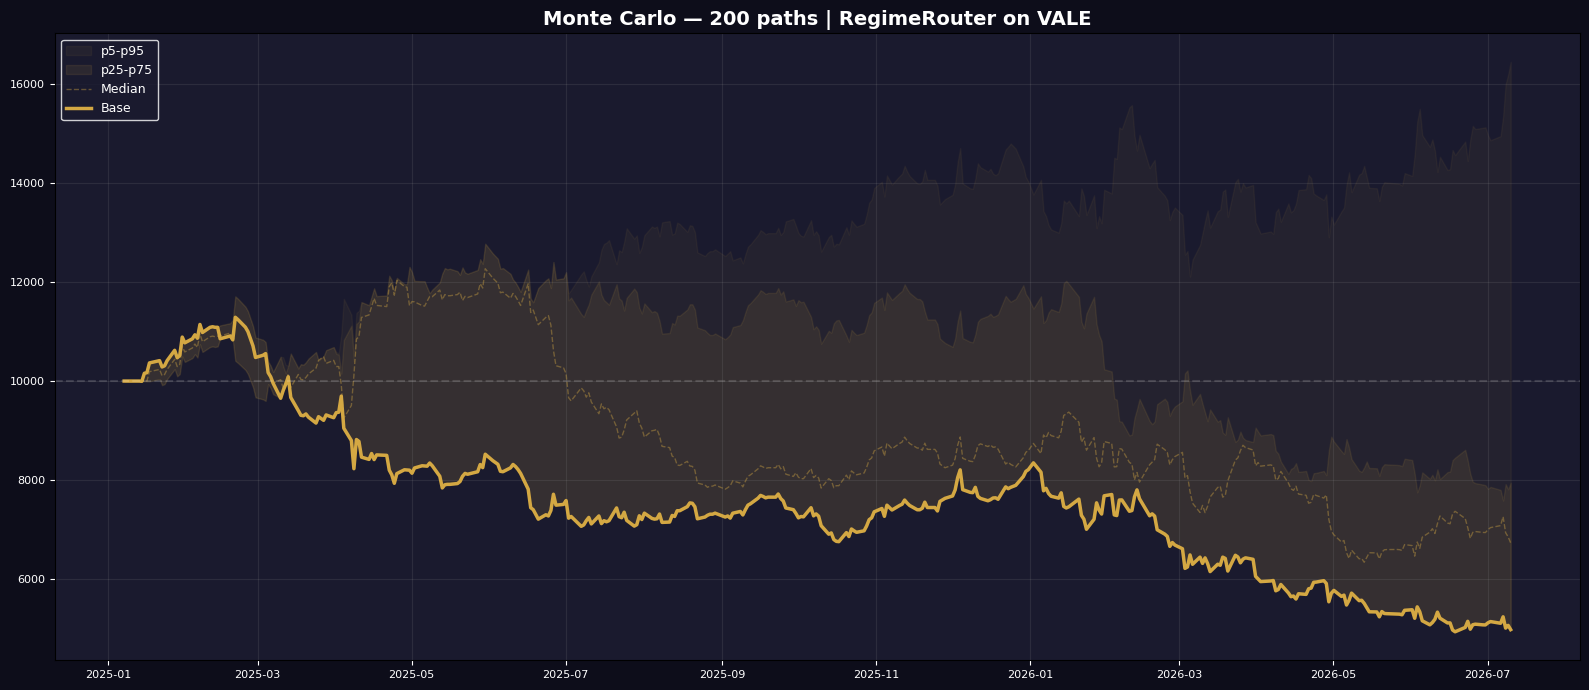

,name,final_equity,total_return_pct,max_drawdown_pct,sharpe,volatility_pct
0,base,4981.571427,-50.184286,-56.254039,-1.338349,31.213612
1,sim_0,4984.306741,-50.156927,-56.229962,-1.337729,31.203098
2,sim_1,4982.531750,-50.174651,-56.242839,-1.338359,31.205578
3,sim_2,16440.281939,64.402819,-22.241946,1.216659,31.460308
4,sim_3,6727.324750,-32.726753,-50.388488,-0.683355,31.563694
5,sim_4,7945.836484,-20.541635,-40.162466,-0.327361,31.732292


In [48]:
mc = monte_carlo_simulate(
    df_test, RegimeRouterStrategy(vol_window=20, regime_percentile=50, mom_window=5),
    MonteCarloConfig(n_simulations=200, noise_bps=8, delay_bars=(0, 3), seed=42),
    config,
)

base = mc.base_equity.set_index('timestamp')['equity']
pcts = mc.percentile_curves

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#0d0d1a')

ax.fill_between(base.index, pcts['p5'], pcts['p95'], color='#D4A843', alpha=0.06, label='p5-p95')
ax.fill_between(base.index, pcts['p25'], pcts['p75'], color='#D4A843', alpha=0.10, label='p25-p75')
ax.plot(base.index, pcts['p50'], color='#D4A843', lw=1, alpha=0.4, ls='--', label='Median')
ax.plot(base.index, base.values, color='#D4A843', lw=2.5, label='Base')
ax.axhline(config.initial_cash, color='white', ls='--', alpha=0.15)

ax.set_title(f'Monte Carlo — 200 paths | RegimeRouter on VALE', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=8)
ax.grid(True, alpha=0.12)
ax.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='white', labelcolor='white', loc='upper left')

fig.tight_layout()
fig.savefig(_root / 'images' / 'backtest_demo_monte_carlo.png', dpi=300, facecolor='#0d0d1a', edgecolor='none', bbox_inches='tight')
plt.show()

mc.summary_metrics.head(6)

## 5. Parameter Heatmap

Grid search: 48 combinations | metric=sharpe
  Best: {'vol_window': 30, 'mom_window': 20, 'regime_percentile': 60} | sharpe=0.1292


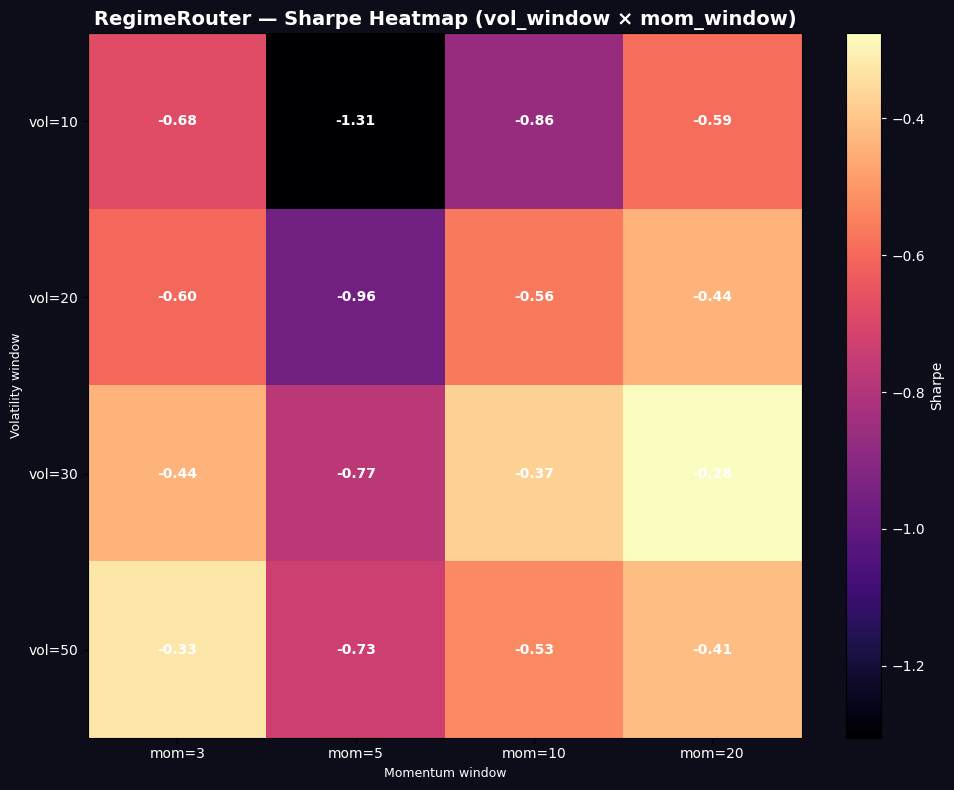

,vol_window,mom_window,regime_percentile,metric_sharpe,metric_total_return_pct,metric_max_drawdown_pct
0,30,20,60,0.129215,-6.369975,-68.214939
1,30,10,60,0.119889,-7.836469,-49.476622
2,50,3,60,0.075805,-12.991725,-46.377855
3,30,3,60,-0.008633,-21.947083,-46.377855
4,50,20,60,-0.051560,-25.506752,-69.730633


In [49]:
gs = grid_search(
    df_train, RegimeRouterStrategy,
    {
        'vol_window': [10, 20, 30, 50],
        'mom_window': [3, 5, 10, 20],
        'regime_percentile': [40, 50, 60],
    },
    metric='sharpe',
    config=config,
)

pivot = gs.all_results.pivot_table(values='_score', index='vol_window', columns='mom_window', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d0d1a')
im = ax.imshow(pivot.values, aspect='auto', cmap='magma')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'mom={int(c)}' for c in pivot.columns], color='white', fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'vol={int(i)}' for i in pivot.index], color='white', fontsize=10)
ax.set_title('RegimeRouter — Sharpe Heatmap (vol_window × mom_window)', color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Momentum window', color='white', fontsize=9)
ax.set_ylabel('Volatility window', color='white', fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.set_ylabel('Sharpe', color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

fig.tight_layout()
fig.savefig(_root / 'images' / 'backtest_demo_heatmap.png', dpi=300, facecolor='#0d0d1a', edgecolor='none', bbox_inches='tight')
plt.show()

gs.all_results.nlargest(5, '_score')[['vol_window', 'mom_window', 'regime_percentile', 'metric_sharpe', 'metric_total_return_pct', 'metric_max_drawdown_pct']].reset_index(drop=True)

## 6. Walk-Forward Performance

  Fold 1: train=2021-07-12 00:00:00-04:00->2022-04-25 00:00:00-04:00 test=2022-05-10 00:00:00-04:00->2022-10-28 00:00:00-04:00 params={'vol_window': 30, 'mom_window': 5, 'regime_percentile': 60} test_sharpe=0.189
  Fold 2: train=2021-07-12 00:00:00-04:00->2022-10-28 00:00:00-04:00 test=2022-11-14 00:00:00-05:00->2023-05-08 00:00:00-04:00 params={'vol_window': 20, 'mom_window': 3, 'regime_percentile': 60} test_sharpe=-1.542
  Fold 3: train=2021-10-05 00:00:00-04:00->2023-05-08 00:00:00-04:00 test=2023-05-23 00:00:00-04:00->2023-11-10 00:00:00-05:00 params={'vol_window': 30, 'mom_window': 3, 'regime_percentile': 60} test_sharpe=-1.119
  Fold 4: train=2022-04-11 00:00:00-04:00->2023-11-10 00:00:00-05:00 test=2023-11-28 00:00:00-05:00->2024-05-20 00:00:00-04:00 params={'vol_window': 30, 'mom_window': 3, 'regime_percentile': 60} test_sharpe=0.487
  Fold 5: train=2022-10-17 00:00:00-04:00->2024-05-20 00:00:00-04:00 test=2024-06-05 00:00:00-04:00->2024-11-22 00:00:00-05:00 params={'vol_window

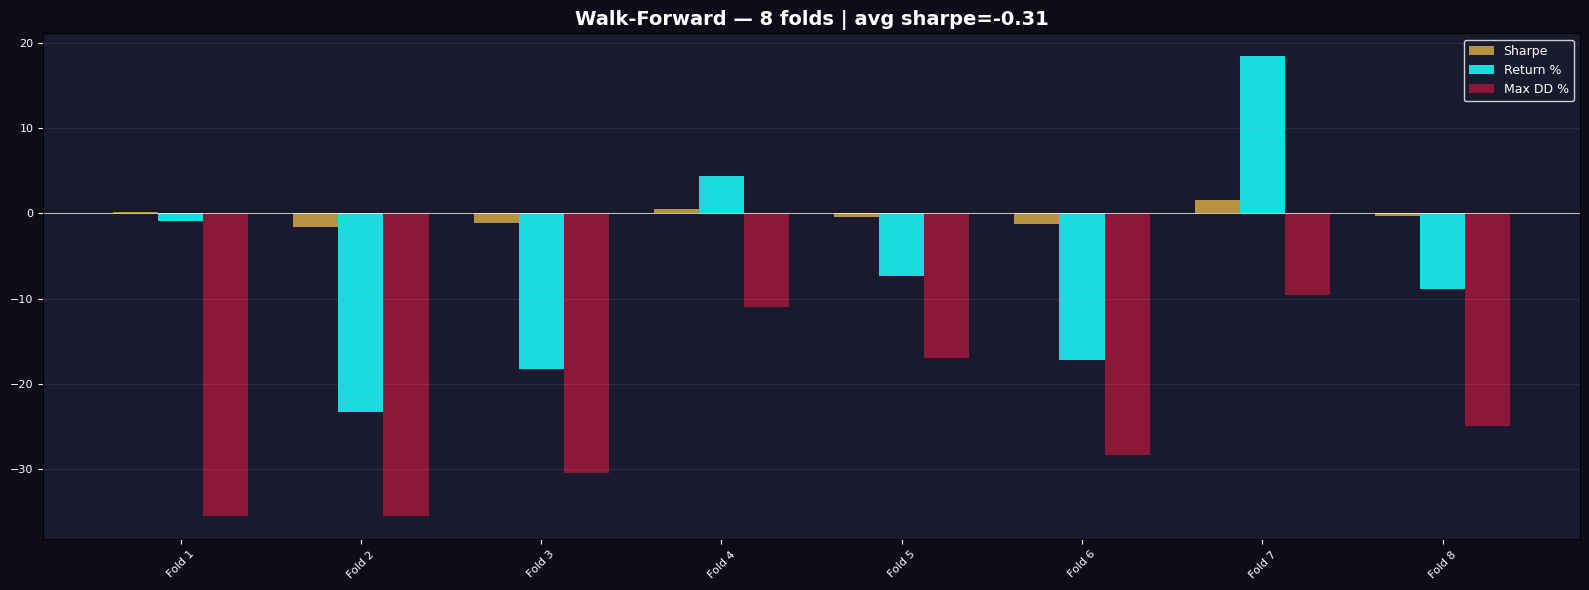

,fold,best_params,test_sharpe,test_total_return_pct,test_max_drawdown_pct
0,1,"{'vol_window': 30, 'mom_window': 5, 'regime_pe...",0.189216,-0.858848,-35.556773
1,2,"{'vol_window': 20, 'mom_window': 3, 'regime_pe...",-1.541939,-23.325799,-35.526916
2,3,"{'vol_window': 30, 'mom_window': 3, 'regime_pe...",-1.119320,-18.201466,-30.490505
3,4,"{'vol_window': 30, 'mom_window': 3, 'regime_pe...",0.487099,4.383981,-11.028351
4,5,"{'vol_window': 10, 'mom_window': 10, 'regime_p...",-0.467337,-7.359852,-16.968536
5,6,"{'vol_window': 20, 'mom_window': 10, 'regime_p...",-1.246310,-17.235810,-28.371652
6,7,"{'vol_window': 10, 'mom_window': 3, 'regime_pe...",1.563282,18.445893,-9.554580
7,8,"{'vol_window': 10, 'mom_window': 3, 'regime_pe...",-0.328704,-8.827248,-24.958473


In [50]:
wf = walk_forward_optimize(
    df, RegimeRouterStrategy,
    {'vol_window': [10, 20, 30], 'mom_window': [3, 5, 10], 'regime_percentile': [40, 50, 60]},
    wf_config=WalkForwardConfig(train_window=400, test_window=120, min_train=200, purge_bars=10),
    metric='sharpe',
    engine_config=config,
)

folds = wf.fold_results

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0d0d1a')

x = np.arange(len(folds))
w = 0.25
sharpes = [f.get('test_sharpe', 0) for f in folds]
returns = [f.get('test_total_return_pct', 0) for f in folds]
dd = [-abs(f.get('test_max_drawdown_pct', 0)) for f in folds]

ax.bar(x - w, sharpes, w, color='#D4A843', alpha=0.85, label='Sharpe')
ax.bar(x, returns, w, color='#18FFFF', alpha=0.85, label='Return %')
ax.bar(x + w, dd, w, color='#FF1744', alpha=0.5, label='Max DD %')

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f["fold"]}' for f in folds], color='white', fontsize=7, rotation=45)
ax.axhline(0, color='white', lw=0.5)
ax.set_title(f'Walk-Forward — {len(folds)} folds | avg sharpe={wf.aggregate_metrics.get("avg_sharpe",0):.2f}', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=8)
ax.grid(True, alpha=0.12, axis='y')
ax.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='white', labelcolor='white', loc='upper right')

fig.tight_layout()
fig.savefig(_root / 'images' / 'backtest_demo_walkforward.png', dpi=300, facecolor='#0d0d1a', edgecolor='none', bbox_inches='tight')
plt.show()

pd.DataFrame(folds)[['fold', 'best_params', 'test_sharpe', 'test_total_return_pct', 'test_max_drawdown_pct']].head(10)

## 7. Stress Tests

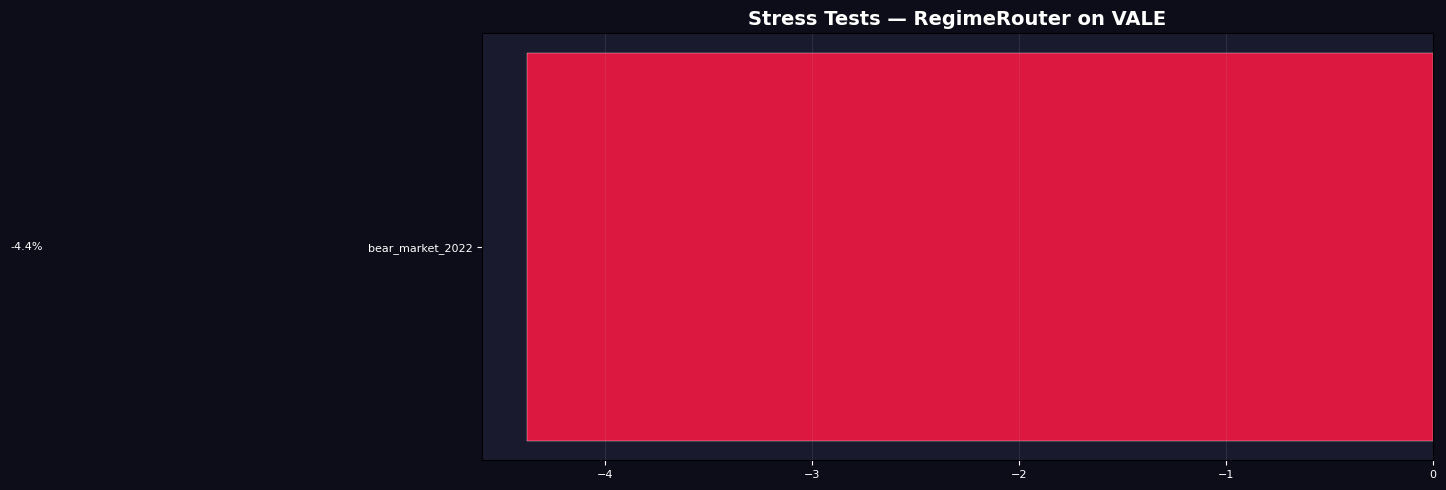

,scenario,description,return_pct,max_drawdown_pct,sharpe
0,bear_market_2022,2022 bear market,-4.374761,-30.982748,0.086825


In [51]:
st = run_stress_tests(df, RegimeRouterStrategy(vol_window=20, regime_percentile=50, mom_window=5), config=config, verbose=False)

sdf = st.summary.dropna(subset=['return_pct'])

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0d0d1a')

scenarios = sdf['scenario'].tolist()
y_pos = np.arange(len(scenarios))
ret_vals = sdf['return_pct'].values

bars = ax.barh(y_pos, ret_vals, color=['#D4A843' if v >= 0 else '#FF1744' for v in ret_vals], alpha=0.85, edgecolor='white', lw=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(scenarios, color='white', fontsize=9)
ax.axvline(0, color='white', lw=0.5)

for i, v in enumerate(ret_vals):
    ax.text(v + (0.3 if v >= 0 else -2.5), i, f'{v:.1f}%', va='center', color='white', fontsize=8)

ax.set_title('Stress Tests — RegimeRouter on VALE', color='white', fontsize=14, fontweight='bold')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white', labelsize=8)
ax.grid(True, alpha=0.12, axis='x')

fig.tight_layout()
fig.savefig(_root / 'images' / 'backtest_demo_stress.png', dpi=300, facecolor='#0d0d1a', edgecolor='none', bbox_inches='tight')
plt.show()

sdf[['scenario', 'description', 'return_pct', 'max_drawdown_pct', 'sharpe']]

## 8. Alpha / Beta Decomposition

In [52]:
r = results['Regime Router']
eq = r.equity_curve.set_index('timestamp')['equity']
bh = df_test.set_index('timestamp')['close']
bh = bh / bh.iloc[0] * config.initial_cash

strat_rets = eq.pct_change().fillna(0)
bh_rets = bh.pct_change().fillna(0)
ab = decompose_alpha_beta(strat_rets, bh_rets, 252)

ab_df = pd.Series(ab).to_frame('value')
ab_df.index = ['Alpha (annual %)', 'Beta', 'Beta Return (annual %)', 'Alpha Return (annual %)', 'R-squared']
ab_df

,value
Alpha (annual %),-48.153952
Beta,0.134276
Beta Return (annual %),6.490066
Alpha Return (annual %),-48.153952
R-squared,0.008870


## 9. Metrics Summary (Full)

In [53]:
pd.Series(results['Regime Router'].metrics).to_frame('value')

,value
final_equity,4981.571427
total_return_pct,-50.184286
cagr_pct,-37.236222
max_drawdown_pct,-56.254039
sharpe,-1.336565
sortino,-1.824417
calmar,-0.661930
trade_count,315.000000
win_rate_pct,0.000000
avg_trade_pct,-5996.938058


## 10. Multi-Asset — B3 Stocks Comparison

In [54]:
tickers = ['VALE', 'PBR', 'ITUB', 'BBD', 'ABEV', 'GGB']
multi = []

for t in tickers:
    try:
        tk = yf.Ticker(t)
        data = tk.history(period='3y')
        data.columns = [c.lower() for c in data.columns]
        data['timestamp'] = data.index
        data = data.dropna(subset=['close']).sort_values('timestamp')

        s = int(len(data) * 0.7)
        data_test = data.iloc[s:]

        r = engine.run(data_test, RegimeRouterStrategy(vol_window=20, regime_percentile=50, mom_window=5))
        m = r.metrics
        multi.append({
            'ticker': t, 'days': len(data_test),
            'ret_%': round(m['total_return_pct'], 1),
            'bh_%': round(m['bh_return_pct'], 1),
            'excess_%': round(m['excess_return_pct'], 1),
            'sharpe': round(m['sharpe'], 2),
            'max_dd_%': round(m['max_drawdown_pct'], 1),
            'alpha_%': round(m['alpha_pct'], 1),
            'beta': round(m['beta'], 2),
        })
    except Exception as e:
        multi.append({'ticker': t, 'error': str(e)[:60]})

pd.DataFrame(multi).set_index('ticker')

,days,ret_%,bh_%,excess_%,sharpe,max_dd_%,alpha_%,beta
ticker,,,,,,,,
VALE,226,-44.1,53.5,-97.6,-1.90,-49.6,-67.4,0.14
PBR,226,-38.2,48.4,-86.6,-1.54,-40.6,-48.8,0.00
ITUB,226,59.1,39.1,20.1,1.89,-11.3,53.8,0.06
BBD,226,38.0,28.5,9.5,1.22,-15.7,38.3,0.10
ABEV,226,16.6,40.6,-24.0,0.69,-16.2,5.2,0.39
GGB,226,-34.8,53.5,-88.3,-1.24,-37.4,-53.2,0.21
